In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
X, y = make_classification(
n_samples=1000,
n_features=2,
n_informative=2,
n_redundant=0,
n_clusters_per_class=1,
random_state=42
)

In [3]:
df = pd.DataFrame(X, columns=["price", "volume"])
df["label"] = y


In [4]:
X = df[["price", "volume"]].values
y = df["label"].values

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


In [7]:
model = Sequential([
Input(shape=(1, 2)),
LSTM(32, return_sequences=False),
Dropout(0.3),
Dense(16, activation="relu"),
Dense(1, activation="sigmoid")
])

In [8]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [9]:
history = model.fit(
X_train, y_train,
validation_data=(X_test, y_test),
epochs=12,
batch_size=32,
verbose=2
)

Epoch 1/12
25/25 - 5s - 193ms/step - accuracy: 0.8675 - loss: 0.6585 - val_accuracy: 0.8750 - val_loss: 0.6342
Epoch 2/12
25/25 - 0s - 9ms/step - accuracy: 0.8963 - loss: 0.6018 - val_accuracy: 0.8950 - val_loss: 0.5705
Epoch 3/12
25/25 - 0s - 9ms/step - accuracy: 0.8988 - loss: 0.5249 - val_accuracy: 0.8900 - val_loss: 0.4894
Epoch 4/12
25/25 - 0s - 9ms/step - accuracy: 0.9075 - loss: 0.4364 - val_accuracy: 0.8950 - val_loss: 0.4091
Epoch 5/12
25/25 - 0s - 9ms/step - accuracy: 0.9062 - loss: 0.3535 - val_accuracy: 0.8950 - val_loss: 0.3448
Epoch 6/12
25/25 - 0s - 8ms/step - accuracy: 0.9050 - loss: 0.2979 - val_accuracy: 0.9000 - val_loss: 0.3008
Epoch 7/12
25/25 - 0s - 12ms/step - accuracy: 0.9062 - loss: 0.2565 - val_accuracy: 0.8950 - val_loss: 0.2740
Epoch 8/12
25/25 - 0s - 13ms/step - accuracy: 0.9137 - loss: 0.2329 - val_accuracy: 0.9000 - val_loss: 0.2566
Epoch 9/12
25/25 - 1s - 24ms/step - accuracy: 0.9137 - loss: 0.2171 - val_accuracy: 0.9050 - val_loss: 0.2454
Epoch 10/12
25

In [10]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", acc)


Test accuracy: 0.9049999713897705


In [11]:
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       100
           1       0.94      0.87      0.90       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.90       200
weighted avg       0.91      0.91      0.90       200

ROC AUC: 0.905


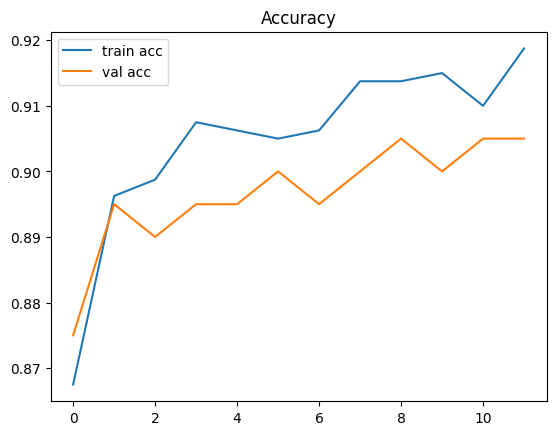

In [12]:
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.legend()
plt.title("Accuracy")
plt.show()


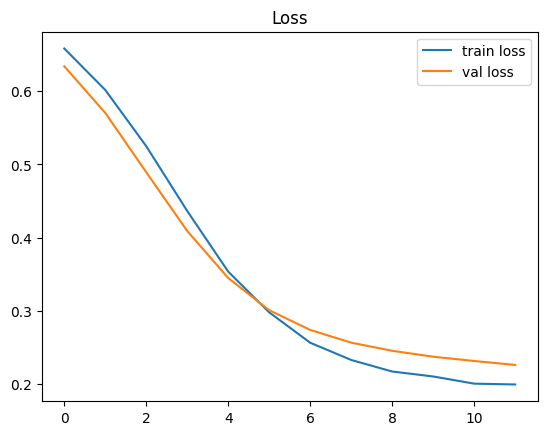

In [13]:
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend()
plt.title("Loss")
plt.show()

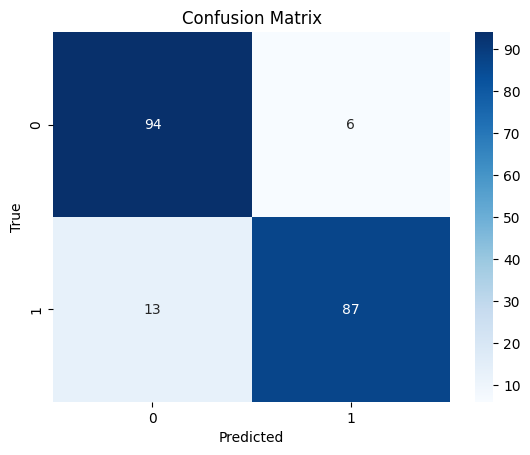

In [14]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()